# Results for observations with multiple images in the FLTS

## Python imports

In [1]:
import Common
import matplotlib.pyplot as pyplt
import numpy as np
import pandas as pd

## Read dataset 

FloraOn images have no observation information (i.e., the GBIF id), hence are excluded.

In [2]:
data = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')
data = data[data.set == 'TEST']
data = data[data.repos != 'FloraOn'][['gbif_id','species','filename']]
data['gbif_id'] = data['gbif_id'].astype(int)
data

,gbif_id,species,filename
0,1945424512,Acacia dealbata,Acacia_dealbata_1945424512_1.jpg
1,2974327900,Acacia dealbata,Acacia_dealbata_2974327900_1.jpg
2,1946199420,Acacia dealbata,Acacia_dealbata_1946199420_3.jpg
3,1945436102,Acacia dealbata,Acacia_dealbata_1945436102_1.jpg
4,1805367892,Acacia dealbata,Acacia_dealbata_1805367892_1.jpg
...,...,...,...
293459,2242774794,Zostera noltii,Zostera_noltii_2242774794_1.jpg
293460,1972305757,Zostera noltii,Zostera_noltii_1972305757_1.jpg
293461,1931477974,Zostera noltii,Zostera_noltii_1931477974_1.jpg
293462,3112502324,Zostera noltii,Zostera_noltii_3112502324_2.jpg


## Identify observations with multiple associated images

In [3]:
cdata = data.groupby(['gbif_id','species']).count().reset_index().rename(columns={ 'filename': 'num_images' })
cdata = cdata[cdata.num_images != 1]
cdata=cdata.sort_values('num_images')
cdata

,gbif_id,species,num_images
6,1024230823,Pancratium maritimum,2
16666,2842051830,Valerianella echinata,2
16671,2842073753,Juncus ranarius,2
16694,2842136659,Bassia scoparia,2
16720,2842189914,Juncus conglomeratus,2
...,...,...,...
8052,2643497078,Erucastrum nasturtiifolium,4
23506,3058933216,Teesdalia coronopifolia,4
5195,2236922216,Trifolium incarnatum,4
17636,2850719910,Trifolium alexandrinum,4


## Calculate a few overall statistics 

In [4]:
cdata2 = cdata[['num_images','gbif_id']].groupby('num_images').count().rename(columns={ 'gbif_id': 'observations' }).reset_index()
cdata2['images'] = cdata2['num_images'] * cdata2['observations']
cdata2

,num_images,observations,images
0,2,1090,2180
1,3,82,246
2,4,12,48
3,6,1,6


In [5]:
print('Observations:',cdata2['observations'].sum(),'Images:',cdata2['images'].sum())

Observations: 1185 Images: 2480


## Calculate aggregate observation scores by averaging image scores

In [6]:
model_index_to_species = [ s.strip() for s in open('model-files/dict.txt', 'r').readlines() ]

def get_top_5_from_scores(scores, result):
    top_5_ranks = scores.argsort()[::-1][:5]
    for i in range(5):
        result.append(model_index_to_species[top_5_ranks[i]])
        result.append(scores[top_5_ranks[i]])
    return result
        
single_img_classif_results = []
multiple_img_classif_results = []

for obs in cdata.itertuples():
    obs_imgs = data[data.gbif_id == obs.gbif_id]
    obs_scores = np.zeros(len(model_index_to_species))
    for img in obs_imgs.itertuples():
        img_scores = np.array([ float(line.strip()) \
                      for line in open('../floralens/detailed-results/'+img.filename+'.score.txt')])
        obs_scores = obs_scores + img_scores # Sum (before averaging outside the loop)
        img_results = get_top_5_from_scores(img_scores, [obs.gbif_id, img.filename, obs.species])
        single_img_classif_results.append(img_results)
    obs_scores = obs_scores / obs.num_images # Take average
    obs_data = get_top_5_from_scores(obs_scores, [obs.gbif_id, obs.num_images, obs.species])
    multiple_img_classif_results.append(obs_data)
    #print( obs_data)

    
single_img_classif_df = pd.DataFrame(single_img_classif_results, 
                                   columns = [
                                       'gbif_id', 'filename', 'species',
                                       'rank1', 'c1',
                                       'rank2', 'c2',
                                       'rank3', 'c3',
                                       'rank4', 'c4',
                                       'rank5', 'c5'
                                   ] )
multiple_img_classif_df = pd.DataFrame(multiple_img_classif_results, 
                                   columns = [
                                       'gbif_id', 'num_images', 'species',
                                       'rank1', 'c1',
                                       'rank2', 'c2',
                                       'rank3', 'c3',
                                       'rank4', 'c4',
                                       'rank5', 'c5'
                                   ] )

## Overview of single image scores (no aggregation)

In [7]:
print('Top-1',
      Common.top1(single_img_classif_df), 
      'Top-5',
      Common.top5(single_img_classif_df), 
      'MRR', 
      Common.mrr(single_img_classif_df))
single_img_classif_df

Top-1 0.6685483870967742 Top-5 0.8560483870967742 MRR 0.7430040322580646


,gbif_id,filename,species,rank1,c1,rank2,c2,rank3,c3,rank4,c4,rank5,c5
0,1024230823,Pancratium_maritimum_1024230823_1.jpg,Pancratium maritimum,Pancratium maritimum,0.600000,Ornithogalum orthophyllum,0.050980,Ornithogalum concinnum,0.050980,Ornithogalum broteroi,0.027451,Ornithogalum arabicum,0.015686
1,1024230823,Pancratium_maritimum_1024230823_2.jpg,Pancratium maritimum,Pancratium maritimum,0.713725,Ornithogalum concinnum,0.047059,Ornithogalum arabicum,0.023529,Ornithogalum broteroi,0.019608,Ornithogalum orthophyllum,0.011765
2,2842051830,Valerianella_echinata_2842051830_7.jpg,Valerianella echinata,Centranthus calcitrapae,0.752941,Valerianella echinata,0.070588,Valerianella discoidea,0.039216,Valerianella coronata,0.035294,Valerianella locusta,0.023529
3,2842051830,Valerianella_echinata_2842051830_2.jpg,Valerianella echinata,Valerianella locusta,0.560784,Valerianella dentata,0.121569,Valerianella echinata,0.054902,Centranthus calcitrapae,0.035294,Anthriscus caucalis,0.031373
4,2842073753,Juncus_ranarius_2842073753_3.jpg,Juncus ranarius,Juncus ranarius,0.407843,Juncus bufonius,0.109804,Asplenium septentrionale,0.043137,Eleocharis acicularis,0.039216,Isolepis setacea,0.035294
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,2518133751,Taxus_baccata_2518133751_28.jpg,Taxus baccata,Taxus baccata,0.972549,Cryptomeria japonica,0.011765,Acacia mearnsii,0.003922,Pittosporum undulatum,0.003922,Acacia saligna,0.003922
2476,2518133751,Taxus_baccata_2518133751_22.jpg,Taxus baccata,Taxus baccata,0.509804,Salix fragilis,0.043137,Arbutus unedo,0.035294,Cryptomeria japonica,0.031373,Salix alba,0.027451
2477,2518133751,Taxus_baccata_2518133751_9.jpg,Taxus baccata,Taxus baccata,0.866667,Pinus pinea,0.019608,Eucalyptus globulus,0.007843,Pinus sylvestris,0.007843,Acacia mearnsii,0.007843
2478,2518133751,Taxus_baccata_2518133751_16.jpg,Taxus baccata,Taxus baccata,0.435294,Olea europaea,0.074510,Quercus suber,0.066667,Salix alba,0.050980,Populus nigra,0.031373


## Overview of aggregate scores

In [8]:
print('Top-1', 
      Common.top1(multiple_img_classif_df), 
      'Top-5',
      Common.top5(multiple_img_classif_df), 
      'MRR',
      Common.mrr(multiple_img_classif_df))
multiple_img_classif_df

Top-1 0.8008438818565401 Top-5 0.9417721518987342 MRR 0.8598312236286919


,gbif_id,num_images,species,rank1,c1,rank2,c2,rank3,c3,rank4,c4,rank5,c5
0,1024230823,2,Pancratium maritimum,Pancratium maritimum,0.656863,Ornithogalum concinnum,0.049020,Ornithogalum orthophyllum,0.031373,Ornithogalum broteroi,0.023529,Ornithogalum arabicum,0.019608
1,2842051830,2,Valerianella echinata,Centranthus calcitrapae,0.394118,Valerianella locusta,0.292157,Valerianella echinata,0.062745,Valerianella dentata,0.060784,Valerianella discoidea,0.029412
2,2842073753,2,Juncus ranarius,Juncus ranarius,0.576471,Juncus bufonius,0.156863,Asplenium septentrionale,0.021569,Eleocharis acicularis,0.019608,Isolepis setacea,0.017647
3,2842136659,2,Bassia scoparia,Alyssum alyssoides,0.168627,Ononis ramosissima,0.131373,Alyssum minutum,0.119608,Jasione crispa,0.050980,Tribulus terrestris,0.029412
4,2842189914,2,Juncus conglomeratus,Juncus conglomeratus,0.970588,Juncus effusus,0.007843,Cladium mariscus,0.001961,Erophaca baetica,0.000000,Lamarckia aurea,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,2643497078,4,Erucastrum nasturtiifolium,Erucastrum nasturtiifolium,0.568627,Sisymbrium irio,0.077451,Coincya monensis,0.055882,Barbarea verna,0.023529,Diplotaxis virgata,0.020588
1181,3058933216,4,Teesdalia coronopifolia,Teesdalia nudicaulis,0.426471,Galium palustre,0.362745,Teesdalia coronopifolia,0.037255,Oenanthe fistulosa,0.021569,Lomelosia simplex,0.020588
1182,2236922216,4,Trifolium incarnatum,Trifolium incarnatum,0.870588,Trifolium pratense,0.011765,Trifolium vesiculosum,0.008824,Fumaria bastardii,0.007843,Centaurea cyanus,0.006863
1183,2850719910,4,Trifolium alexandrinum,Trifolium alexandrinum,0.701961,Coincya monensis,0.038235,Trifolium ochroleucon,0.017647,Hieracium laevigatum,0.011765,Scorzonera humilis,0.009804


## Derive plot with results

In [9]:
font = {'family' : 'normal',
        'size'   : 12}

pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (12,6)

a_2_imgs = multiple_img_classif_df[multiple_img_classif_df.num_images == 2]

a_more_than_2 = multiple_img_classif_df[multiple_img_classif_df.num_images > 2]

plot_data = pd.DataFrame([
    [
        'Single image', 
        Common.top1(single_img_classif_df), Common.top5(single_img_classif_df), Common.mrr(single_img_classif_df)
    ],
    [   'Aggregation',
        Common.top1(multiple_img_classif_df), Common.top5(multiple_img_classif_df), Common.mrr(multiple_img_classif_df)
    ],
    [   'Agg. (3+ images)',
        Common.top1(a_more_than_2), Common.top5(a_more_than_2), Common.mrr(a_more_than_2)
    ],
], columns=['Set','Top-1','Top-5','MRR'])
plot_data

,Set,Top-1,Top-5,MRR
0,Single image,0.668548,0.856048,0.743004
1,Aggregation,0.800844,0.941772,0.859831
2,Agg. (3+ images),0.831579,0.989474,0.897368


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


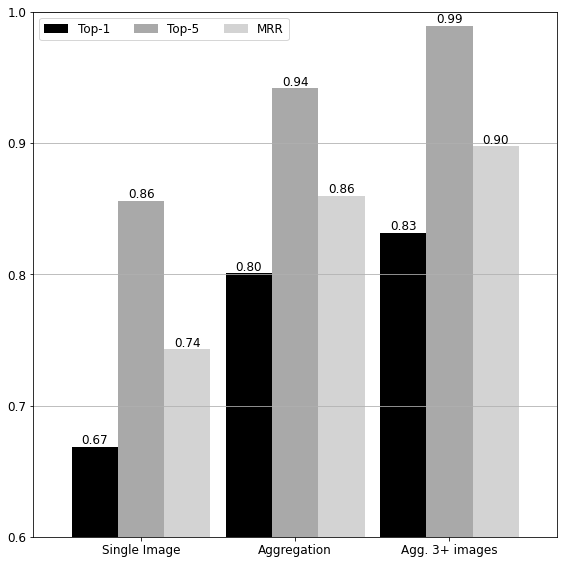

In [10]:
font = {'family' : 'normal',
        'size'   : 12}

pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (8,8)

plt = plot_data.plot.bar(x='Set',y=['Top-1', 'Top-5', 'MRR'],color=['black','darkgray','lightgray'],width=0.9)
plt.legend(loc='upper left', ncol=3)
plt.set_ylim([0.60,1.0])
plt.set_xlabel('')
plt.set_yticks([0.60,0.70,0.80,0.90,1.0])
plt.grid(axis='y')
plt.set_xticklabels(['Single Image','Aggregation', 'Agg. 3+ images'], rotation=0, ha='center')
for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().tight_layout()
plt.get_figure().savefig("plot_images/multiple_image_results.pdf")